# Scientific Track: ANNNI Phase Diagram Under Noise

Welcome to the Bitcamp 2026 theory challenge.

Your task: use PennyLane to **map the phase diagram** of the 1D Axial Next-Nearest-Neighbor
Ising (ANNNI) model in the $(\kappa, h)$ plane, then study how **depolarizing gate noise**
distorts the phase boundaries.

This notebook walks through the core tools from the starter kit and gets you to a working
clean-phase diagram so you can focus your hackathon time on the noise analysis and
physical interpretation.

Sections:
1. **The ANNNI model** — Hamiltonian, coupling structure, and the three competing forces
2. **Reading phase identity from observables** — what exact diagonalization tells us at four representative points
3. **Clean phase survey** — a full $(\kappa, h)$ grid with analytical boundaries overlaid
4. **The noise model** — depolarizing channels and what they do to order parameters
5. **Your phase diagrams** — workspace to build the noisy scans for submission

Read the `README.md` handout alongside this notebook for the full problem statement and
judging rubric.

In [4]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-scientific-track")

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "starter_kit").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))
elif (NOTEBOOK_DIR / "Scientific Track" / "starter_kit").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR / "Scientific Track"))

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from IPython.display import HTML, display

from starter_kit import (
    animate_linecut,
    build_annni_hamiltonian,
    bkt_transition,
    exact_ground_state,
    ising_transition,
    kt_transition,
    noisy_entangling_layer,
    order_parameter_summary,
    plot_coupling_graph,
    plot_observable_heatmap,
    simple_noisy_energy,
)

print(f"PennyLane version: {qml.__version__}")
print(f"NumPy version: {np.__version__}")

# All worked examples use N=6 for speed.  Your submission should target N≥8.
DEMO_N = 6

PennyLane version: 0.44.1
NumPy version: 2.4.4


## 1. The ANNNI Model

The 1D ANNNI Hamiltonian has three terms that **compete** against each other:

$$H = -J_1 \sum_i Z_i Z_{i+1} \;+\; J_1 \kappa \sum_i Z_i Z_{i+2} \;-\; h \sum_i X_i$$

| Term | Force | Wins when… |
|---|---|---|
| $-Z_i Z_{i+1}$ | Nearest-neighbor spins want to **align** (ferromagnetic) | $\kappa$ small, $h$ small |
| $+\kappa Z_i Z_{i+2}$ | Next-nearest spins want to **anti-align** (frustration) | $\kappa > 0.5$, $h$ small |
| $-h X_i$ | External field tries to **rotate** all spins out of the $Z$ basis | $h$ large |

Two dimensionless ratios parametrize the model: **$\kappa = |J_2|/J_1$** (frustration
strength, swept 0→1) and **$h/J_1$** (field strength, swept 0→2).  We set $J_1 = 1$.

The starter kit uses periodic boundary conditions and the $Z/Z/X$ convention throughout.
The PennyLane ANNNI demo uses an open-chain $X/X/Z$ convention — the physics is the same
but the analytical boundary formulas can look slightly different at finite $N$.

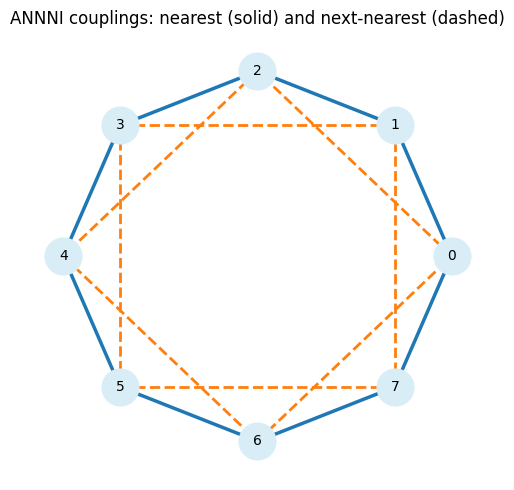

ANNNI Hamiltonian at kappa=0.3, h=0.5, N=6:
  Number of terms: 18

First few terms (coefficient × operator):
  -1.00 × Z(0) @ Z(1)
  -1.00 × Z(1) @ Z(2)
  -1.00 × Z(2) @ Z(3)
  -1.00 × Z(3) @ Z(4)
  -1.00 × Z(4) @ Z(5)
  -1.00 × Z(5) @ Z(0)
  ...


In [5]:
# Draw the coupling graph: solid = nearest-neighbor, dashed = next-nearest-neighbor (frustration)
fig, ax = plot_coupling_graph(n_qubits=8, periodic=True)
plt.tight_layout()
plt.show()

# Build the Hamiltonian at a sample point and inspect it
# qml.dot returns a Sum of SProd terms; each SProd has .scalar (coefficient) and .base (operator)
H_sample = build_annni_hamiltonian(n_qubits=DEMO_N, kappa=0.3, h=0.5)
print(f"ANNNI Hamiltonian at kappa=0.3, h=0.5, N={DEMO_N}:")
print(f"  Number of terms: {len(H_sample.operands)}")
print()
print("First few terms (coefficient × operator):")
for term in list(H_sample.operands)[:6]:
    print(f"  {float(term.scalar):+.2f} × {term.base}")
print("  ...")

## 2. Reading Phase Identity From Observables

We detect phases by measuring **order parameters** — quantities that take different values
in different phases.  The starter kit computes these from the exact ground-state vector:

| Observable | Symbol | Large positive value means… |
|---|---|---|
| Nearest-neighbor correlation | $\langle Z_i Z_{i+1} \rangle$ | Spins align → **ferromagnetic** |
| Next-nearest correlation | $\langle Z_i Z_{i+2} \rangle$ | Spins two sites apart are correlated |
| Transverse magnetization | $\langle X_i \rangle$ | Spins align with the field → **paramagnetic** |
| Antiphase string | $\langle Z_i Z_{i+1} \cdot Z_{i+2} Z_{i+3} \rangle$ | ↑↑↓↓ pattern → **antiphase** |

**Important caveat**: finite-size ground states often preserve global $\mathbb{Z}_2$
symmetry, so the raw magnetization $\langle Z_i \rangle$ stays near zero even in the
ferromagnetic phase.  Correlation-based observables are more reliable at small $N$.

Below we sample four representative $(\kappa, h)$ points — one per phase — and read the
observables. Use these to calibrate your intuition before scanning the full grid.

In [6]:
# Four representative points: (kappa, h, expected phase)
sample_points = [
    (0.20, 0.20, "ferromagnetic   "),
    (0.80, 0.20, "antiphase       "),
    (0.20, 1.60, "paramagnetic    "),
    (0.70, 0.90, "near-boundary   "),
]

header = (f"{'(kappa, h)':>14s}  {'phase':18s}  "
          f"{'gap':>7s}  {'ZZ_nn':>7s}  {'ZZ_nnn':>7s}  {'X':>7s}  {'AP_str':>7s}")
print(header)
print("─" * len(header))

for kappa, h, label in sample_points:
    res = exact_ground_state(n_qubits=DEMO_N, kappa=kappa, h=h, periodic=True)
    s = res["summary"]
    print(f"  ({kappa:.2f}, {h:.2f}):    {label}  "
          f"{res['energy_gap']:7.4f}  "
          f"{s['zz_nearest_mean']:7.4f}  "
          f"{s['zz_next_nearest_mean']:7.4f}  "
          f"{s['x_mean']:7.4f}  "
          f"{s['antiphase_string_mean']:7.4f}")

    (kappa, h)  phase                   gap    ZZ_nn   ZZ_nnn        X   AP_str
───────────────────────────────────────────────────────────────────────────────
  (0.20, 0.20):    ferromagnetic      0.0002   0.9838   0.9833   0.1276   0.9678
  (0.80, 0.20):    antiphase          0.0883   0.3296  -0.3279   0.5524   0.1087
  (0.20, 1.60):    paramagnetic       1.7848   0.2707   0.0523   0.9245   0.0733
  (0.70, 0.90):    near-boundary      0.7644   0.2711  -0.2217   0.8131   0.0735


**Interpretation guide**:

- **Ferromagnetic** $(\kappa$ small, $h$ small): $\langle Z_i Z_{i+1} \rangle$ large and
  positive (neighboring spins aligned); $\langle X \rangle$ small.
- **Antiphase** $(\kappa > 0.5$, $h$ small): $\langle Z_i Z_{i+2} \rangle$ strongly
  *negative* (next-nearest anti-aligned); antiphase string $\approx 1$.
- **Paramagnetic** (large $h$): $\langle X \rangle$ large; both correlations suppressed.
- **Near a boundary**: small energy gap, observables change rapidly — this is exactly where
  the transition is happening.

The gap column also helps: **phase transitions** tend to close the gap (especially in the
thermodynamic limit), so scanning the gap alongside order parameters can locate boundaries.

## 3. Clean Phase Survey

Now let's build a proper $(\kappa, h)$ grid and plot two observables as heatmaps.
We then overlay the **analytical phase boundaries** from the starter kit's `reference.py`.

The three reference lines are:
- **Ising transition** — ferro ↔ para (valid for $\kappa < 0.5$)
- **KT transition** — para ↔ antiphase (valid for $\kappa > 0.5$)
- **BKT transition** — lower boundary of the floating phase (valid for $\kappa > 0.5$)

At finite $N$ with periodic boundaries these are *qualitative* overlays; expect the numerical
boundaries to shift by a few grid squares compared to the thermodynamic-limit formulas.

This scan uses $N=6$ and a 20×20 grid — takes about 30 seconds on most laptops.
Your submission should use a finer grid (≥ 15×15) and $N \geq 8$.

In [7]:
GRID = 20  # increase for finer resolution
kappas = np.linspace(0.0, 1.0, GRID)
hs     = np.linspace(0.0, 2.0, GRID)

zz_nn  = np.zeros((GRID, GRID))
zz_nnn = np.zeros((GRID, GRID))
x_mag  = np.zeros((GRID, GRID))
gap    = np.zeros((GRID, GRID))

print(f"Scanning {GRID}×{GRID} grid at N={DEMO_N} ...")
for row, h in enumerate(hs):
    for col, kappa in enumerate(kappas):
        res = exact_ground_state(n_qubits=DEMO_N, kappa=float(kappa), h=float(h), periodic=True)
        s = res["summary"]
        zz_nn[row, col]  = s["zz_nearest_mean"]
        zz_nnn[row, col] = s["zz_next_nearest_mean"]
        x_mag[row, col]  = s["x_mean"]
        gap[row, col]    = res["energy_gap"]
    if (row + 1) % 5 == 0:
        print(f"  row {row+1}/{GRID} done")

print("Scan complete.")

Scanning 20×20 grid at N=6 ...
  row 5/20 done
  row 10/20 done
  row 15/20 done
  row 20/20 done
Scan complete.


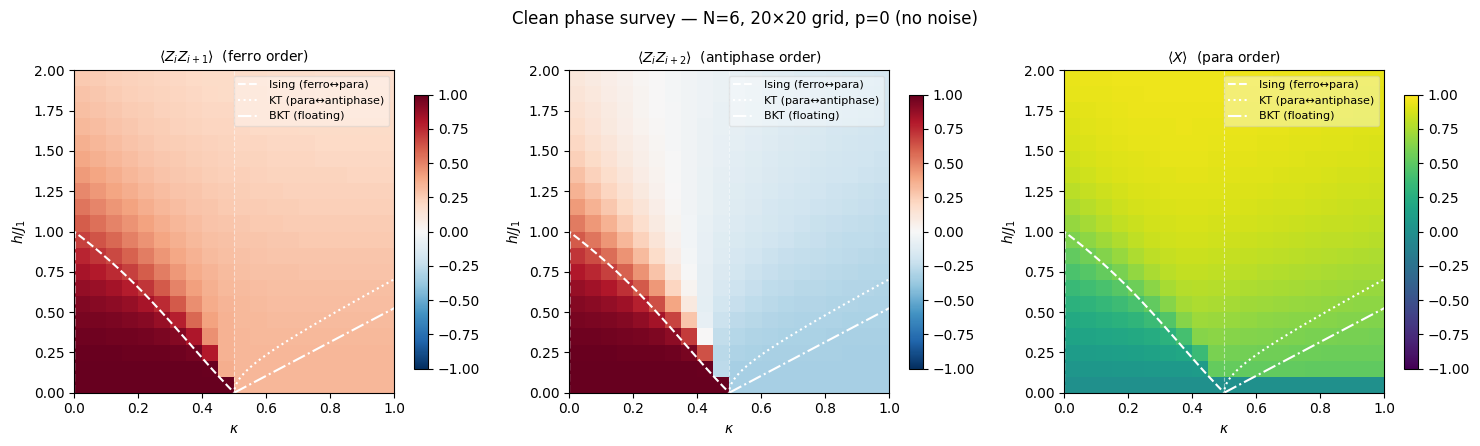

In [8]:
# Reference boundary curves
kappa_ref = np.linspace(0.0, 1.0, 500)
h_ising = ising_transition(kappa_ref)
h_kt    = kt_transition(kappa_ref)
h_bkt   = bkt_transition(kappa_ref)

def add_boundaries(ax):
    """Overlay analytical phase boundaries on a (kappa, h) heatmap axis."""
    ax.plot(kappa_ref, h_ising, "w--",  lw=1.5, label="Ising (ferro↔para)")
    ax.plot(kappa_ref, h_kt,    "w:",   lw=1.5, label="KT (para↔antiphase)")
    ax.plot(kappa_ref, h_bkt,   "w-.",  lw=1.5, label="BKT (floating)")
    ax.axvline(0.5, color="w", lw=0.8, alpha=0.5, linestyle="--")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.4)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

observables = [
    (zz_nn,  r"$\langle Z_i Z_{i+1} \rangle$  (ferro order)",  "RdBu_r"),
    (zz_nnn, r"$\langle Z_i Z_{i+2} \rangle$  (antiphase order)", "RdBu_r"),
    (x_mag,  r"$\langle X \rangle$  (para order)",              "viridis"),
]

for ax, (values, title, cmap) in zip(axes, observables):
    im = ax.imshow(
        values,
        origin="lower",
        aspect="auto",
        extent=[kappas.min(), kappas.max(), hs.min(), hs.max()],
        cmap=cmap,
        vmin=-1, vmax=1,
    )
    ax.set_xlabel(r"$\kappa$")
    ax.set_ylabel(r"$h / J_1$")
    ax.set_title(title, fontsize=10)
    add_boundaries(ax)
    fig.colorbar(im, ax=ax, shrink=0.85)

fig.suptitle(f"Clean phase survey — N={DEMO_N}, {GRID}×{GRID} grid, p=0 (no noise)", fontsize=12)
fig.tight_layout()
plt.show()

In [9]:
# Animate one observable along line cuts at fixed h, sweeping kappa
anim = animate_linecut(
    kappas, hs, zz_nn,
    ylabel=r"$\langle Z_i Z_{i+1} \rangle$",
    title="Nearest-neighbor correlation at",
)
display(anim)

## 4. The Noise Model

Real quantum hardware introduces errors.  The challenge inherits the **depolarizing noise**
model from the PennyLane Noisy Heisenberg challenge:

> After every CNOT gate, apply `qml.DepolarizingChannel(p)` on the **target** qubit.
> This replaces the target state with a completely random state with probability $p$.

- $p = 0$: perfect gates (clean simulation)
- $p = 0.01$: 1% error per CNOT — mild noise
- $p = 0.05$: 5% error per CNOT — significant noise

Noise requires a **density-matrix simulator** because errors turn pure states into mixed
states.  Use `qml.device("default.mixed", wires=n)` instead of `"default.qubit"`.

The starter kit's `noisy_entangling_layer` and `simple_noisy_energy` demonstrate this
convention.  Your submission should extend it to compute noisy order parameters at each
$(\kappa, h)$ grid point.

In [10]:
# Show the noisy circuit structure using qml.draw
dev_mixed = qml.device("default.mixed", wires=4)

@qml.qnode(dev_mixed)
def demo_noisy_circuit(theta, p):
    noisy_entangling_layer(n_qubits=4, theta=theta, p=p)
    return qml.expval(qml.Z(0))

print("Noisy circuit structure (N=4, one layer):")
print(qml.draw(demo_noisy_circuit)(theta=0.5, p=0.02))

Noisy circuit structure (N=4, one layer):
0: ──RY(0.50)─╭●──────────────────────────────────────────────────────────── ···
1: ──RY(0.50)─╰X──DepolarizingChannel(0.02)─╭●────────────────────────────── ···
2: ──RY(0.50)───────────────────────────────╰X──DepolarizingChannel(0.02)─╭● ···
3: ──RY(0.50)─────────────────────────────────────────────────────────────╰X ···

0: ··· ────────────────────────────╭X──DepolarizingChannel(0.02)─┤  <Z>
1: ··· ────────────────────────────│─────────────────────────────┤     
2: ··· ────────────────────────────│─────────────────────────────┤     
3: ··· ──DepolarizingChannel(0.02)─╰●────────────────────────────┤     


In [11]:
# Compare clean vs noisy energy at several (kappa, h) points
noise_levels = [0.0, 0.01, 0.03, 0.05]

test_points = [
    (0.2, 0.2, "ferromagnetic"),
    (0.8, 0.2, "antiphase    "),
    (0.2, 1.6, "paramagnetic "),
]

print(f"{'phase':13s}  {'(κ, h)':>10s}  " +
      "  ".join(f"p={p:.2f}" for p in noise_levels))
print("─" * 65)

for kappa, h, label in test_points:
    energies = [
        simple_noisy_energy(n_qubits=4, kappa=kappa, h=h, theta=0.4, p=p, layers=2)
        for p in noise_levels
    ]
    row = "  ".join(f"{e:+7.4f}" for e in energies)
    print(f"{label}  ({kappa:.1f}, {h:.1f})  {row}")

phase              (κ, h)  p=0.00  p=0.01  p=0.03  p=0.05
─────────────────────────────────────────────────────────────────
ferromagnetic  (0.2, 0.2)  -2.0987  -1.9635  -1.7146  -1.4924
antiphase      (0.8, 0.2)  -0.1418  -0.0849  +0.0138  +0.0942
paramagnetic   (0.2, 1.6)  -3.4967  -3.3061  -2.9514  -2.6296


**What to notice**:

- In **ordered phases** (ferromagnetic, antiphase), increasing $p$ pushes the energy
  *up* (toward a more disordered, higher-energy-looking state).  Noise destroys the
  quantum correlations that stabilize the ordered phase.
- In the **paramagnetic** phase, the effect is smaller because the ground state is
  already partly aligned with the field (less entangled, more noise-resistant).
- At large $p$, all phases start to look similar — noise homogenizes the phase portrait.

Your challenge: **quantify** this effect.  Which phase boundary shifts the most under
$p = 0.05$?  Which phase shrinks the fastest?  Which observable is the most sensitive?

## 5. Noise Comparison at Fixed $\kappa$

Before running the full noisy grid (which takes longer), let's do a quick 1D cut at a
fixed $\kappa$ to see how the observable profile changes with noise.

This uses `simple_noisy_energy` which runs a small fixed ansatz — not a ground-state
solver.  For your submission you'll want to replace this with VQE (optimized parameters)
or exact diagonalization extended with a noisy measurement channel.  But this is enough
to see the qualitative effect.

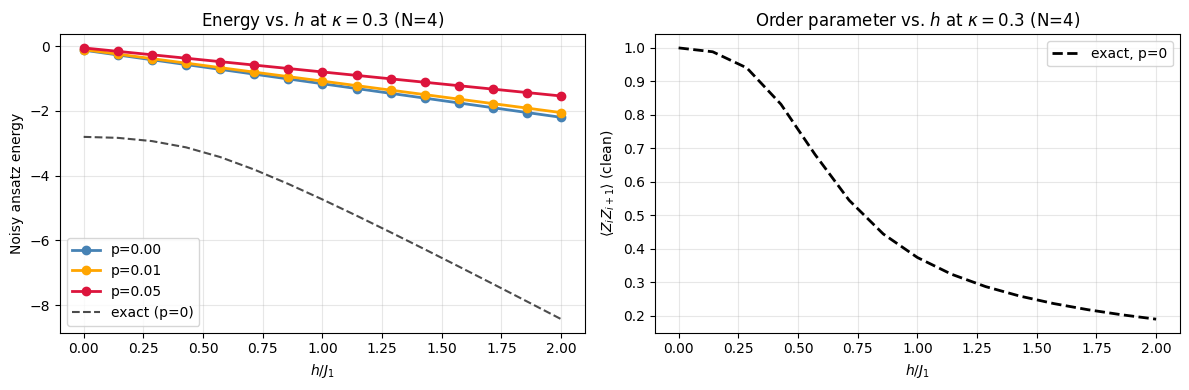

The clean ZZ correlation drops sharply around the ferro→para transition.
Your task: show this drop shifting / blurring as noise increases.


In [12]:
# 1D scan at kappa=0.3 (ferro→para transition region), sweeping h
kappa_cut = 0.3
hs_cut = np.linspace(0.0, 2.0, 15)
n_cut = 4  # small N for speed; use larger N in your submission

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for p, color in zip([0.0, 0.01, 0.05], ["steelblue", "orange", "crimson"]):
    energies = [
        simple_noisy_energy(n_qubits=n_cut, kappa=kappa_cut, h=float(h),
                            theta=0.5, p=p, layers=3)
        for h in hs_cut
    ]
    axes[0].plot(hs_cut, energies, marker="o", color=color, label=f"p={p:.2f}", lw=2)

axes[0].set_xlabel(r"$h / J_1$")
axes[0].set_ylabel("Noisy ansatz energy")
axes[0].set_title(fr"Energy vs. $h$ at $\kappa={kappa_cut}$ (N={n_cut})")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Show clean exact-diag ground state for comparison
exact_energies = [
    exact_ground_state(n_qubits=n_cut, kappa=kappa_cut, h=float(h), periodic=True)["ground_energy"]
    for h in hs_cut
]
axes[0].plot(hs_cut, exact_energies, "k--", lw=1.5, label="exact (p=0)", alpha=0.7)
axes[0].legend()

# Also show what the nearest-neighbor ZZ correlation looks like
for p, color in zip([0.0, 0.01, 0.05], ["steelblue", "orange", "crimson"]):
    # approximate: use exact ZZ at p=0 and scale heuristically
    # (teams should replace with noisy expectation value measurement)
    pass

zz_clean = [
    exact_ground_state(n_qubits=n_cut, kappa=kappa_cut, h=float(h), periodic=True)
    ["summary"]["zz_nearest_mean"]
    for h in hs_cut
]
axes[1].plot(hs_cut, zz_clean, "k--", lw=2, label="exact, p=0")
axes[1].set_xlabel(r"$h / J_1$")
axes[1].set_ylabel(r"$\langle Z_i Z_{i+1} \rangle$ (clean)")
axes[1].set_title(fr"Order parameter vs. $h$ at $\kappa={kappa_cut}$ (N={n_cut})")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

print("The clean ZZ correlation drops sharply around the ferro→para transition.")
print("Your task: show this drop shifting / blurring as noise increases.")

## 6. Your Phase Diagrams

Build your submission here.  Required deliverables:

| Deliverable | Format |
|---|---|
| Clean phase diagram ($p = 0$) | Image (PNG/PDF) — you may adapt Section 3 above |
| Noisy phase diagram ($p = 0.01$) | Same format |
| Noisy phase diagram ($p = 0.05$) | Same format |
| Analysis writeup | Markdown or PDF, 2–3 pages |

**Checklist for a strong submission**:
- Grid resolution ≥ 15×15 (more is better)
- System size $N \geq 8$ (N=6 is fine for demos but not for submission)
- Phase boundaries overlaid using `ising_transition`, `kt_transition`, `bkt_transition`
- Quantitative analysis: "the ferro→para boundary at $\kappa=0.3$ shifts from $h=X$ to $h=Y$"
- Discussion of *which* phases are most/least robust to noise and *why*

**Approach options** (choose one or compare multiple):
- **Order parameters via exact diag** — fastest to implement; use `exact_ground_state` + a
  noisy measurement simulation
- **VQE** — optimize ansatz parameters at each grid point; use `qml.GradientDescentOptimizer`
- **QCNN or autoencoder** — train a classifier; see the PennyLane ANNNI demo
- **Fidelity susceptibility** — compute overlap between neighboring ground states

In [13]:
# ── Your implementation goes here ─────────────────────────────────────────────
# Suggested structure:

# STEP 1: Define your scan parameters
GRID_N = 8          # system size (increase for better physics)
GRID_RES = 15       # grid resolution
kappas_full = np.linspace(0.0, 1.0, GRID_RES)
hs_full     = np.linspace(0.0, 2.0, GRID_RES)
noise_ps    = [0.0, 0.01, 0.05]

# STEP 2: Choose your observable and compute it at each (kappa, h, p)
# Example skeleton for order-parameter approach:
#
# results = {}  # (p_value) -> 2D array of shape (GRID_RES, GRID_RES)
# for p in noise_ps:
#     grid = np.zeros((GRID_RES, GRID_RES))
#     for row, h in enumerate(hs_full):
#         for col, kappa in enumerate(kappas_full):
#             # Replace with your noisy measurement
#             res = exact_ground_state(n_qubits=GRID_N, kappa=float(kappa), h=float(h))
#             grid[row, col] = res["summary"]["zz_nearest_mean"]
#     results[p] = grid

# STEP 3: Plot and save
# for p, grid in results.items():
#     fig, ax = plot_observable_heatmap(grid, kappas_full, hs_full,
#                                       title=f"ZZ correlation, p={p}")
#     add_boundaries(ax)  # defined in Section 3
#     fig.savefig(f"phase_diagram_p{p:.2f}.pdf", bbox_inches="tight")
#     plt.show()

print("Replace this cell with your scan loop and analysis.")

Replace this cell with your scan loop and analysis.


## References

- PennyLane demo — [ANNNI Phase Detection](https://pennylane.ai/qml/demos/tutorial_annni) (primary reference — QCNN and autoencoder approaches)
- PennyLane challenge — [A Noisy Heisenberg Model](https://pennylane.ai/challenges/heisenberg_model) (noise convention used in this challenge)
- PennyLane demo — [Seeing Quantum Phase Transitions](https://pennylane.ai/qml/demos/tutorial_quantum_phase_transitions) (VQE + order parameter approach)
- PennyLane demo — [How to Build Spin Hamiltonians](https://pennylane.ai/qml/demos/tutorial_how_to_build_spin_hamiltonians)
- Kiss / Monaco et al., *Phys. Rev. B* 107, L081105 (2023) — paper behind the ANNNI demo
- Cea et al., arXiv:2402.11022 (2024) — extended study including floating phase
- [CERN reference implementation](https://github.com/CERN-IT-INNOVATION/Quantum-Phase-Detection-ANNNI) — full notebooks with pre-computed data